In [1]:
import polars as pl
import ast
import re
from procompa import get_project_root
PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [2]:
#filter for big complexes from complex portal that dont have a sufficient/ no homology pdb match
pdb_mapping_intr_big = pl.read_csv(data_dir/ "complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv").filter(pl.col("match_class").is_in(["no_homology_match", "no_sufficient_match"])).filter(pl.col("n_proteins") > 2)

In [8]:
#get only CF statistics for the interesting complexes
all_cf_output = pl.read_csv(data_dir / "Pipeline/10_all_CP_complexes/all_pdb_present_10_all_CP_complexes_pool_pipeline_complexes_combfold_results.csv") #only 613 instead of 634, cause pipeline cant handle some identifiers yet
intresting_no_struc_complexes = all_cf_output.filter(pl.col("complex_ac").is_in(pdb_mapping_intr_big["complex_ac"].implode()))

# add n proteins
intresting_no_struc_complexes = intresting_no_struc_complexes.join(pdb_mapping_intr_big.select(["complex_ac", "n_proteins"]), on="complex_ac", how="left")

In [9]:
# get max cf confidence for each run
shared = ["complex_ac", "identifiers", "correct_pred_count", "correct_pred_rank", "n_pairs_used", "pairs_used"]

frames = [
    intresting_no_struc_complexes.select(
        *shared,
        pl.lit(i).alias("pred_rank"),
        pl.col(f"pred_{i}").alias("pred_stoic"),
        pl.col(f"CF_{i}_n_assemblies").alias("n_assemblies"),
        pl.col(f"CF_{i}_confidence").alias("CF_confidence"),
        pl.col(f"CF_{i}_reason").alias("CF_reason"),
    )
    for i in [1, 2, 3]
]

# true stoichiometry as pred_rank=0
frames.append(
    intresting_no_struc_complexes.select(
        *shared,
        pl.lit(0).alias("pred_rank"),
        pl.lit(None).cast(pl.String).alias("pred_stoic"),
        pl.col("CF_true_n_assemblies").alias("n_assemblies"),
        pl.col("CF_true_confidence").alias("CF_confidence"),
        pl.col("CF_true_reason").alias("CF_reason"),
    )
)

long_intresting_no_struc_complexes = (
    pl.concat(frames)
    .sort("complex_ac", "pred_rank")
    .filter(
        (pl.col("pred_rank") != 0) |
        (pl.col("correct_pred_rank") == "none")
    )
    .with_columns(
        pl.col("CF_confidence")
        .map_elements(
            lambda s: max(ast.literal_eval(s).values()) if s not in (None, "{}") else None,
            return_dtype=pl.Float64,
        )
        .alias("CF_confidence_max")
    )
)

In [10]:
#best CF for each run (of stoichiometry that matches betwwen CP and PDB, or just pdb, if CP doesn't have a stoichiometry given)
long_intresting_no_struc_complexes = long_intresting_no_struc_complexes.with_columns(
    pl.col("CF_confidence")
    .map_elements(
        lambda s: max(ast.literal_eval(s).values()) if s not in (None, "{}") else None,
        return_dtype=pl.Float64,
    )
    .alias("CF_confidence_max")
)

In [11]:
complex_summary = (
    long_intresting_no_struc_complexes
    .sort("CF_confidence_max", descending=True, nulls_last=True)
    .group_by("complex_ac")
    .first()
)


In [12]:
#complexes where CF was convinced
confident_complexes = complex_summary.filter(pl.col("CF_confidence_max") > 80)

confident_complexes = confident_complexes.select(["complex_ac", 'identifiers', 'correct_pred_rank', 'pred_rank', 'pred_stoic', 'CF_confidence_max'])

In [13]:
confident_complexes = confident_complexes.join(pdb_mapping_intr_big, how="left", on="complex_ac")

In [14]:
#for the no sufficient match check overlap ( so what is in the pdb file)
pdb_match = pl.read_csv(data_dir/'complete_complex_pdb_mapping_v2/homology_pdb_mapping/all_candidate_matches.csv')
#confident_complexes

#This row is a mapping between CPX-607 and 3uku. extra poretin as one unit from pdb wasnt mapped, so it say both (Cp complex and ppdb file) have an 
# unmapped chain, hence the no sufficneint category, but might just be cause pdb subunit is only 150 aa?
#is stochiometry the sane
#is for short part od preotin good macthc found)

In [15]:
confident_complexes_pdb_match_info = confident_complexes.join(pdb_match, on= ["complex_ac", "pdb_id"], how="left")

In [16]:
confident_complexes_pdb_match_info = confident_complexes_pdb_match_info.sort(
    [
        pl.when(pl.col("match_class") == "no_homology_match").then(1)
          .when(pl.col("match_class") == "no_sufficient_match").then(0)
          .alias("_sort_key"),
        pl.col("CF_confidence_max"),
    ],
    descending=[False, True],
)

In [17]:
# add correct n proteisn (so nottaking into account urs)

confident_complexes_pdb_match_info = confident_complexes_pdb_match_info.with_columns(
    pl.col("identifiers").str.split("|")
    .list.eval(pl.element().filter(~pl.element().str.starts_with("CHEBI:") & ~pl.element().str.starts_with("URS")))
    .list.len().alias("n_proteins")
)

In [18]:
confident_complexes_pdb_match_info.write_csv(data_dir / "CP_complexes_no_struct_coverage/confident_CF_complexes_with_pdb_match_info.csv")

In [19]:
# add which protein have not found a pdb match 

def _unmatched_proteins(stoic_str: str, chain_map_str: str | None) -> list[str]:
    complex_proteins = {p.split("(")[0].upper() for p in stoic_str.split("|")}
    if chain_map_str is None:
        return sorted(complex_proteins)
    matched = set()
    for entry in chain_map_str.split(","):
        matched.add(entry.split(":")[0].upper())
        for p in re.findall(r'\(([^)]+)\)', entry):
            matched.add(p.upper())
    return sorted(complex_proteins - matched)

confident_complexes_pdb_match_info = confident_complexes_pdb_match_info.with_columns(
    pl.struct("identifiers", "matching_hits")
    .map_elements(
        lambda r: _unmatched_proteins(r["identifiers"], r["matching_hits"]),
        return_dtype=pl.List(pl.String),
    )
    .alias("unmatched_proteins")
)

In [20]:
# get mmseq results for unmatched proteins (make sure that tehre really is no good match)
unmatched_set = set(
    confident_complexes_pdb_match_info["unmatched_proteins"].explode().drop_nulls().to_list()
)

mmseqs = pl.read_parquet(PRJ_ROOT / "scripts/mmseq_homology_match/mmseqs/mmseqs_run_max_sensitivity/results/mmseqs_new_identity_similarity_max_sensitivity.parquet").filter(
    pl.col("protein_id").is_in(unmatched_set)
)

In [3]:
# how man chaisn do the pdb entrie shave that were matched with mmseq
pdb_sifts = pl.read_csv(
    "/cluster/project/beltrao/kdammer/master_thesis/data/pdb/pdb_chain_uniprot.csv",
    has_header=True,
    comment_prefix="#",
    schema_overrides={"PDB_BEG": pl.String, "PDB_END": pl.String},
)

In [4]:
# 1. Count unique UniProt accessions per PDB in SIFTS
pdb_n_proteins = (
    pdb_sifts.group_by("PDB")
    .agg(pl.col("SP_PRIMARY").n_unique().alias("n_unique_proteins"))
)

In [21]:
# 2. PDB IDs are always 4 chars, so slice is safer than split
# "8ohs_C" -> "8ohs"
mmseqs = mmseqs.with_columns(
    pl.col("hit_pdb_id").str.slice(0, 4).alias("pdb_id")
).join(
    pdb_n_proteins, left_on="pdb_id", right_on="PDB", how="left"
).drop("pdb_id")

## Do i find a better macth with Blast identity

In [22]:
confident_complexes_pdb_match_info = pl.read_csv(data_dir / "CP_complexes_no_struct_coverage/confident_CF_complexes_with_pdb_match_info.csv")
mmseqs = pl.read_parquet(PRJ_ROOT / "scripts/mmseq_homology_match/mmseqs/mmseqs_run_max_sensitivity/results/mmseqs_new_identity_similarity_max_sensitivity.parquet")


# Extract all UniProt accessions from identifiers
proteins_in_complexes = (
    confident_complexes_pdb_match_info
    .select(pl.col("identifiers").str.split("|").explode())
    .select(pl.col("identifiers").str.extract(r"^([^(]+)", 1).alias("acc"))
    .filter(
        ~pl.col("acc").str.starts_with("CHEBI") &
        ~pl.col("acc").str.starts_with("URS")
    )
    .get_column("acc")
    .unique()
)

# only mmseq results for proteins taht are n complex of intrest
mmseqs_filtered = mmseqs.filter(pl.col("protein_id").is_in(proteins_in_complexes.to_list()))

In [3]:
# only mmseq results if identity is high enoug
mmseqs_filtered = mmseqs_filtered.filter((pl.col("identity_percent") > 30) | (pl.col("blast_identity_percent") > 30))

#aligned sequence has to be at least 30 aa long
mmseqs_filtered = mmseqs_filtered.filter((pl.col("alnlen") > 30))



In [ ]:
#mmseqs_filtered.write_parquet(data_dir / "CP_complexes_no_struct_coverage/sanity_checks/mmseq_no_Strcut_filtered.parquet")

In [7]:
# list fopr eahc protein what db hits t has
protein_to_pdbs = (
    mmseqs_filtered
    .with_columns(pl.col("hit_pdb_id").str.split("_").list.first().alias("pdb_id"))
    .group_by("protein_id")
    .agg(pl.col("pdb_id").unique().alias("pdb_ids"))
)

In [8]:
# Per-complex protein extraction (keeps complex_ac)
complex_proteins = (
    confident_complexes_pdb_match_info
    .select("complex_ac", "identifiers") #slght change compared to 2 cells before cause i need complex acc
    .with_columns(pl.col("identifiers").str.split("|").alias("identifiers"))
    .explode("identifiers")
    .select(
        "complex_ac",
        pl.col("identifiers").str.extract(r"^([^(]+)", 1).alias("protein_id")
    )
    .filter(
        ~pl.col("protein_id").str.starts_with("CHEBI") &
        ~pl.col("protein_id").str.starts_with("URS")
    )
)

# Join mmseqs hits and aggregate per complex + pdb_id
complex_pdb_hits = (
    complex_proteins
    .join(protein_to_pdbs, on="protein_id", how="left")
    .explode("pdb_ids")
    .rename({"pdb_ids": "pdb_id"})
    .drop_nulls("pdb_id")
    .group_by("complex_ac", "pdb_id")
    .agg(
        pl.col("protein_id").alias("proteins"),
        pl.col("protein_id").len().alias("n_proteins_with_hit"),
    )
    .sort("complex_ac", "n_proteins_with_hit", descending=[False, True])
)

In [12]:
complex_pdb_hits = (
    complex_pdb_hits
    .join(
        complex_proteins.group_by("complex_ac").agg(pl.col("protein_id").n_unique().alias("n_proteins_complex")),
        on="complex_ac",
        how="left",
    )
    .join(
        pdb_n_proteins.with_columns(pl.col("PDB").str.to_lowercase().alias("pdb_id")),
        on="pdb_id",
        how="left",
    )
    .rename({"n_unique_proteins": "n_proteins_pdb"})
)

In [25]:
complex_pdb_hits = complex_pdb_hits.drop("PDB")

In [26]:
with_fracs = complex_pdb_hits.with_columns(
    (pl.col("n_proteins_with_hit") / pl.col("n_proteins_complex")).alias("frac_complex"),
    (pl.col("n_proteins_with_hit") / pl.col("n_proteins_pdb")).alias("frac_pdb"),
)

In [ ]:
#complex_pdb_hits.write_parquet(data_dir / "CP_complexes_no_struct_coverage/complex_pdb_hits.parquet")

In [27]:
best_frac_complex = (
    with_fracs
    .filter(pl.col("frac_complex").is_not_null())
    .sort("frac_complex", descending=True)
    .group_by("complex_ac")
    .first()
    .with_columns(pl.lit("frac_complex").alias("best_by"))
)


best_frac_pdb = (
    with_fracs
    .filter(pl.col("frac_pdb").is_not_null())
    .sort("frac_pdb", descending=True)
    .group_by("complex_ac")
    .first()
    .with_columns(pl.lit("frac_pdb").alias("best_by"))
)

best_frac_pdb_multi = (
    with_fracs
    .filter(pl.col("frac_pdb").is_not_null() & (pl.col("n_proteins_pdb") > 1))
    .sort("frac_pdb", descending=True)
    .group_by("complex_ac")
    .first()
    .with_columns(pl.lit("frac_pdb_multi").alias("best_by"))
)


best_per_complex = (
    pl.concat([best_frac_complex, best_frac_pdb, best_frac_pdb_multi])
    .sort("complex_ac", "best_by")
)

In [28]:
#remove rows where odb matc for compelx was the same
best_per_complex = best_per_complex.unique(subset=["complex_ac", "pdb_id"], maintain_order=True)

In [29]:
#add relevant information
confident_complexes_pdb_match_info = confident_complexes_pdb_match_info.select(['complex_ac', 'identifiers', 'correct_pred_rank', 'CF_confidence_max', 'match_class'])

best_per_complex = best_per_complex.join(
    confident_complexes_pdb_match_info,
    on="complex_ac",
    how="left",
)

In [ ]:
# adding annotation from Cp and pdb
'''
best_per_complex = pl.read_parquet(data_dir / "CP_complexes_no_struct_coverage/complex_pdb_hits_best_per_complex.parquet")
CP_PDB_annotation = pl.read_csv(data_dir / "CP_complexes_no_struct_coverage/complex_pdb_annotations_map.csv")

best_per_complex = best_per_complex.join(
    CP_PDB_annotation.select(["complex_ac", "pdb_id", "cp_annotation", "pdb_annotation"]),
    on=["complex_ac", "pdb_id"],
    how="left",
)
'''

In [5]:
best_per_complex.write_parquet(data_dir / "CP_complexes_no_struct_coverage/complex_pdb_hits_best_per_complex.parquet")

## Look for minimal set of pdb files that can cover my complex portal complex

In [4]:
confident_complexes_pdb_match_info = pl.read_csv(data_dir / "CP_complexes_no_struct_coverage/confident_CF_complexes_with_pdb_match_info.csv")

complex_proteins = (
    confident_complexes_pdb_match_info
    .select("complex_ac", "identifiers") #slght change compared to 2 cells before cause i need complex acc
    .with_columns(pl.col("identifiers").str.split("|").alias("identifiers"))
    .explode("identifiers")
    .select(
        "complex_ac",
        pl.col("identifiers").str.extract(r"^([^(]+)", 1).alias("protein_id")
    )
    .filter(
        ~pl.col("protein_id").str.starts_with("CHEBI") &
        ~pl.col("protein_id").str.starts_with("URS")
    )
)

best_per_complex = pl.read_parquet(data_dir / "CP_complexes_no_struct_coverage/complex_pdb_hits.parquet")

In [17]:
from math import ceil

def greedy_set_cover(
    candidates: list[tuple[str, frozenset]], target: frozenset, min_frac: float
) -> tuple[list[str], int]:
    """Greedy set cover. Returns (selected_pdb_ids, n_proteins_covered)."""
    n_req = ceil(min_frac * len(target))                                       # how mnay prtoeins needed to be covered until I can stop (rounded up)
    covered, selected, pool = frozenset(), [], list(candidates)
    while len(covered) < n_req and pool:
        i = max(range(len(pool)), key=lambda i: len(pool[i][1] - covered))
        pdb, prots = pool.pop(i)
        print(f"Selected {pdb} covering {len(prots - covered)} new proteins, total covered: {len(covered | prots)} / {n_req}")
        if not (new := prots - covered):
            print("No new proteins covered by", pdb, "remaining:", n_req - len(covered))
            break
        covered |= new
        selected.append(pdb)
    return selected, len(covered)


# target proteins per complex (UniProt only, already filtered in complex_proteins)
target_by_ac = {
    row["complex_ac"]: frozenset(row["protein_id"])
    for row in complex_proteins.group_by("complex_ac")
    .agg(pl.col("protein_id"))
    .iter_rows(named=True)
}

# candidates per complex: list of (pdb_id, frozenset of matching proteins)
candidates_by_ac = {
    row["complex_ac"]: [
        (pdb, frozenset(prots))
        for pdb, prots in zip(row["pdb_id"], row["proteins"])
    ]
    for row in complex_pdb_hits
    .group_by("complex_ac")
    .agg("pdb_id", "proteins")
    .iter_rows(named=True)
}

cover_rows = []
for ac, target in target_by_ac.items():
    candidates = candidates_by_ac.get(ac, [])
    pdbs_100, n_100 = greedy_set_cover(candidates, target, 1.0)
    pdbs_75, n_75  = greedy_set_cover(candidates, target, 0.75)
    cover_rows.append({
        "complex_ac":         ac,
        "n_target_proteins":  len(target),
        "cover_100_pdbs":     pdbs_100,
        "cover_100_n_pdbs":   len(pdbs_100),
        "cover_100_n_covered": n_100,
        "cover_75_pdbs":      pdbs_75,
        "cover_75_n_pdbs":    len(pdbs_75),
        "cover_75_n_covered": n_75,
    })

pdb_set_cover = pl.DataFrame(cover_rows)

Selected 1t7d covering 2 new proteins, total covered: 2 / 3
Selected 3f1s covering 1 new proteins, total covered: 3 / 3
Selected 1t7d covering 2 new proteins, total covered: 2 / 3
Selected 3f1s covering 1 new proteins, total covered: 3 / 3
Selected 5zwm covering 18 new proteins, total covered: 18 / 18
Selected 5zwm covering 18 new proteins, total covered: 18 / 14
Selected 5nrl covering 27 new proteins, total covered: 27 / 29
Selected 8h6j covering 2 new proteins, total covered: 29 / 29
Selected 5nrl covering 27 new proteins, total covered: 27 / 22
Selected 4p1w covering 2 new proteins, total covered: 2 / 3
Selected 9wmv covering 1 new proteins, total covered: 3 / 3
Selected 4p1w covering 2 new proteins, total covered: 2 / 3
Selected 9wmv covering 1 new proteins, total covered: 3 / 3
Selected 3hnf covering 2 new proteins, total covered: 2 / 4
Selected 1xsm covering 2 new proteins, total covered: 4 / 4
Selected 3hnf covering 2 new proteins, total covered: 2 / 3
Selected 1xsm covering 2 n

In [15]:
pdb_set_cover.write_parquet(data_dir / "CP_complexes_no_struct_coverage/minimal_complex_pdb_set_cover.parquet")

## How many complexes assembles for diff sizes

In [3]:
all_CP_complexes = pl.read_csv(data_dir/ "Pipeline/10_all_CP_complexes/all_pdb_present_10_all_CP_complexes_pool_pipeline_complexes_combfold_results.csv")

In [ ]:
# add how many chains ar ein that complex (only taking into account Uniprot ids)
all_CP_complexes = all_CP_complexes.with_columns(
    pl.col("identifiers")
    .map_elements(
        lambda s: sum(
            max(int(x.split("(")[1].rstrip(")") ), 1)
            for x in s.split("|")
            if x.split("(")[0].isalnum()
        ),
        return_dtype=pl.Int32,
    )
    .alias("n_chain")
)

In [7]:
# for how many complexes of sizes between 10 to 30 chains did CF have an output (this chain sizes are based on the Monte Carlo tree search paper)- to see howoften cf has an output for compelxes this size

CP_complexes_MC_sizes = all_CP_complexes.filter(pl.col("n_chain").is_between(10, 30))

CP_complexes_MC_sizes_output = CP_complexes_MC_sizes.with_columns(
    pl.when(pl.col("correct_pred_rank").is_in(["unknown", "1"]))
    .then(pl.col("CF_1_n_assemblies"))
    .when(pl.col("correct_pred_rank") == "2")
    .then(pl.col("CF_2_n_assemblies"))
    .when(pl.col("correct_pred_rank") == "3")
    .then(pl.col("CF_3_n_assemblies"))
    .when(pl.col("correct_pred_rank") == "none")
    .then(pl.col("CF_true_n_assemblies"))
    .alias("n_assemblies_best")
)

In [8]:
CP_complexes_MC_sizes_output.write_csv(PRJ_ROOT / "tmp/CP_complexes_MC_sizes_output.csv")

In [9]:
print(PRJ_ROOT / "tmp/CP_complexes_MC_sizes_output.csv")

/cluster/project/beltrao/kdammer/master_thesis/tmp/CP_complexes_MC_sizes_output.csv


## Do all the Cf outputs have all chains?

In [ ]:
import os, re
import polars as pl
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

cf_dir = Path("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/10_all_CP_complexes/CombFold")

def expected_chains(name):
    return sum(int(n) for n in re.findall(r'x(\d+)', name.replace("_pool_output", "")))

def pdb_chains(pdb_path):
    data = pdb_path.read_bytes()
    atom_lines = [l for l in data.split(b'\n') if l[:4] == b'ATOM']
    chains     = {l[21] for l in atom_lines}
    nan_chains = {l[21] for l in atom_lines if b'nan' in l[30:54]}
    return len(chains), len(nan_chains)

def process_folder(d):
    assembled = Path(d.path) / "assembled_results"
    if not assembled.exists():
        return []
    expected = expected_chains(d.name)
    rows = []
    for pdb in assembled.glob("output_clustered_*.pdb"):
        n_chains, n_nan_chains = pdb_chains(pdb)
        rows.append({
            "path": str(pdb),
            "expected_chains": expected,
            "actual_chains": n_chains,
            "nan_chains": n_nan_chains,
        })
    return rows

dirs = [d for d in os.scandir(cf_dir) if d.name.endswith("_pool_output")]

with ThreadPoolExecutor(max_workers=32) as ex:
    results = list(ex.map(process_folder, dirs))

df = pl.DataFrame(
    [row for folder in results for row in folder]
).with_columns(
    (pl.col("expected_chains") == pl.col("actual_chains")).alias("chain_count_match"),
    (pl.col("nan_chains") == 0).alias("no_nan"),
    (
        (pl.col("expected_chains") == pl.col("actual_chains")) & (pl.col("nan_chains") == 0)
    ).alias("ok"),
)

# takes abo5 min, only nan for CPX 1602 and not matching chains where the filenmae had to be abbreviated

In [3]:
df.write_csv(data_dir / "CP_complexes_no_struct_coverage/sanity_checks/CF_output_chain_check.csv")

## Confidence score based on complex confidence level

In [2]:
import polars as pl, json, ast

CF_out = pl.read_csv(data_dir / "Pipeline/10_all_CP_complexes/all_pdb_present_10_all_CP_complexes_pool_pipeline_complexes_combfold_results.csv")

BASE = "/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/10_all_CP_complexes/CombFold"

COLS = ["CF_1_confidence","CF_2_confidence","CF_3_confidence","pred_1","pred_2","pred_3"]

def best(row):
    best_conf, best_p = -1.0, None
    for n in [1, 2, 3]:
        conf_str, pred_str = row[f"CF_{n}_confidence"], row[f"pred_{n}"]
        if conf_str is None or pred_str is None:
            continue
        conf = ast.literal_eval(conf_str)
        if not conf:
            continue
        k = max(conf, key=conf.get)
        if conf[k] > best_conf:
            best_conf = conf[k]
            stoich = json.loads(pred_str.split("},")[0] + "}")
            folder = "_".join(f"{ac}x{c}" for ac, c in sorted(stoich.items())) + "_pool_output"
            best_p = f"{BASE}/{folder}/assembled_results/output_clustered_{k}.pdb"
    return {"cf_confidence": best_conf, "path": best_p}

out = (
    CF_out.select(["complex_ac"] + COLS)
    .with_columns(
        pl.struct(COLS)
        .map_elements(best, return_dtype=pl.Struct({"cf_confidence": pl.Float64, "path": pl.String}))
        .alias("r")
    )
    .select("complex_ac", pl.col("r").struct.field("cf_confidence"), pl.col("r").struct.field("path"))
)

In [20]:
# add confidence level:
db_complexes = pl.read_csv( data_dir/ "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator = "\t")
db_complexes = db_complexes.select(["#Complex ac", "Evidence Code"])

db_complexes = db_complexes.with_columns(
    confidence_score = pl.when(pl.col("Evidence Code").str.contains("ECO:0000353"))
                     .then(pl.lit(5.0))
                     .when(pl.col("Evidence Code").str.contains("ECO:0005547"))
                     .then(pl.lit(3.0))
                     .when(pl.col("Evidence Code").str.contains("ECO:0005546"))
                     .then(pl.lit(4.0))
).rename({"Evidence Code": "evidence_code"})


In [10]:
out = out.join(db_complexes.rename({"#Complex ac": "complex_ac"}), on="complex_ac", how="left")

Text(0, 0.5, 'CF confidence')

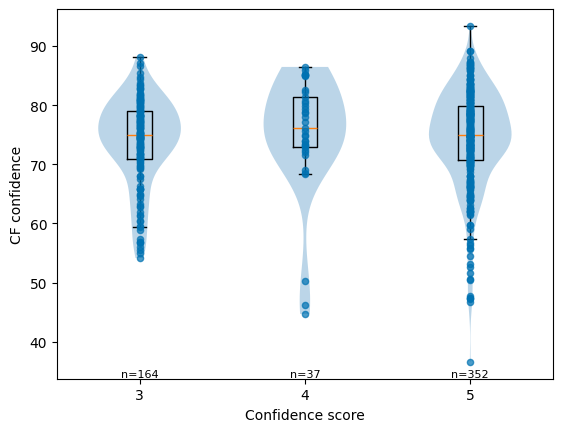

In [23]:
groups = (
    out.filter(pl.col("cf_confidence") != -1.0)
    .sort("confidence_score")
    .group_by("confidence_score", maintain_order=True)
    .agg(pl.col("cf_confidence"))
)

fig, ax = plt.subplots()

xs = groups["cf_confidence"].to_list()
labels = groups["confidence_score"].cast(pl.Int32).to_list()

ax.violinplot(xs, showextrema=False)
ax.boxplot(xs, widths=0.15, showfliers=False)


for i, vals in enumerate(xs, 1):
    ax.scatter([i] * len(vals), vals, color="#0072B2", alpha=0.7, zorder=3, s=20)
    ax.text(i, ax.get_ylim()[0], f"n={len(vals)}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(range(1, len(groups) + 1))
ax.set_xticklabels(labels)
ax.set_xlabel("Confidence score")
ax.set_ylabel("CF confidence")